# 该脚本使用线性回归方法，删除数据残差较大的到时数据

In [2]:
# 载入 TomoATT 数据处理函数
import sys
sys.path.append('../utils')
import functions_for_data as ffd

# 1. 读取到时数据文件

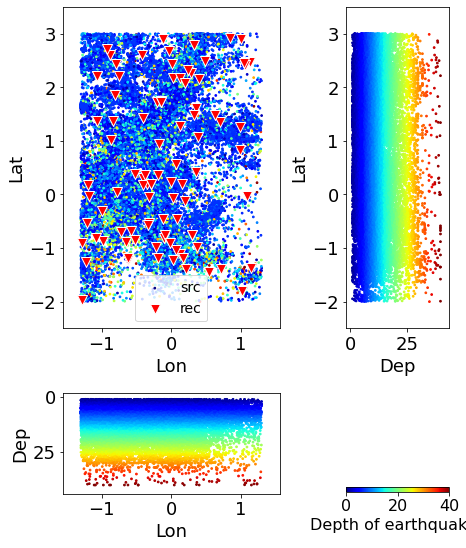

In [3]:
# 读取数据
fname = "output_data/step1_src_rec_indom.dat"
[ev_info_obs, st_info_obs] = ffd.read_src_rec_file(fname)

# 数据画图（可选） fname = None 可以不保存图片
ffd.fig_ev_st_distribution_dep(ev_info_obs, st_info_obs, fname = None)

# 2. 初步删除 outlier 数据，避免这些极端偏离值影响计算回归直线

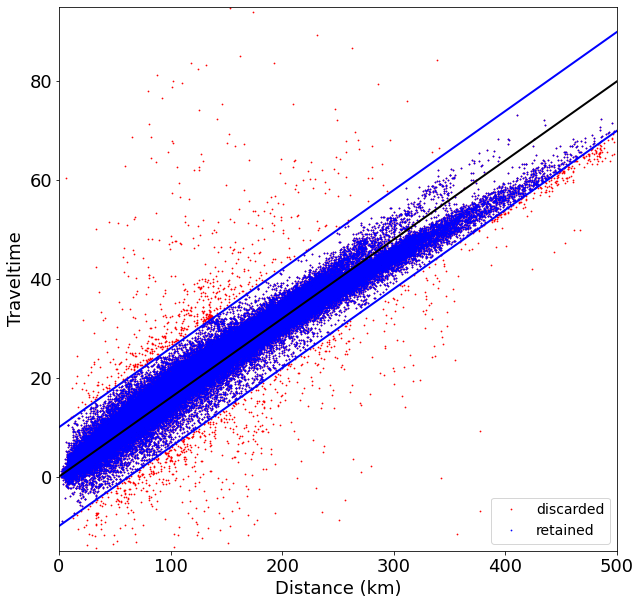

In [4]:
# 筛选范围：当 走时 > slope * 距离 + intercept + up 或者 走时 < slope * 距离 + intercept + down 时，认为是异常数据，剔除掉。
slope = 0.16    # 斜率
intercept = 0   # 截距
up = 10         # 上限
down = -10      # 下限

# 地震与台站直线距离范围（hypocentral distance）
dis_min = 0 
dis_max = 500

# 删除 走时残差大于阈值，以及震源距超过限制范围的数据 （fname = None 可以不保存图片）
ev_remove_outlier = ffd.fig_data_plot_remove_outliers(ev_info_obs,st_info_obs,slope,intercept,up,down,dis_min,dis_max, fname = "figs/step2_data_remove_outlier.png")

# 3. 删除震中距（epicentral distance）超过 100 km 的数据

从 震源距-走时 图像可发现，当震中距超过一定距离时（图中300 km时较为明显），会出现两支数据。

下面一支走时较小，是Pn波，上面一支走时较大，是Pg波

由于 TomoATT 计算的是首达时，因此在较小震中距时，应该使用 Pg 波，震中距较大时，使用Pn波。

但是由于区分两个震相的临界震中距依赖速度结构，Moho面位置，震源深度等因素，通常难以确定。

通常情况下，当震中距小于 100 km时，绝大多数首达震相是 Pg 波。为了避免数据污染，这里我们删除所有震中距大于 100 km的数据，同时删除明确的Pn震相，以确保数据确实是首达P波到时

a is slope, b is intercept, SEE is standard error of estimate


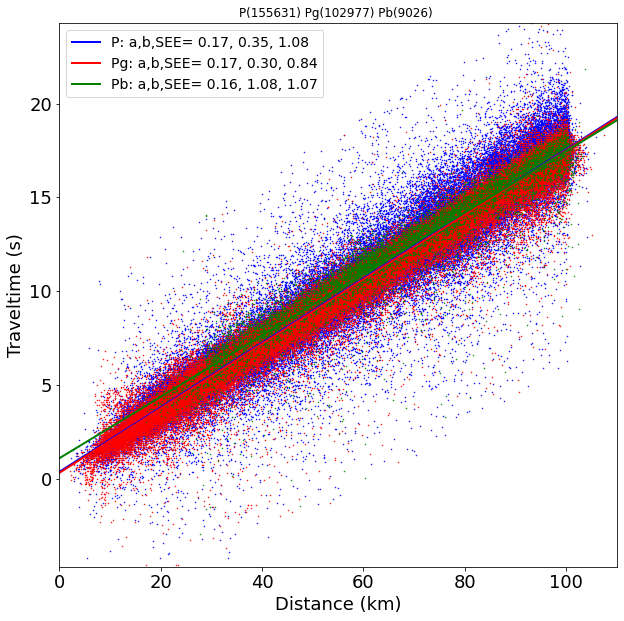

In [5]:
# 删除震中距在 [epi_dis1, epi_dis2] 范围之内的数据
epi_dis1 = 100      
epi_dis2 = 1000000
ev_limit_dis = ffd.limit_epi_dis(ev_remove_outlier, st_info_obs, epi_dis1, epi_dis2)

# 在 100 km 以内的震中距范围内，Pn 通常不是首达震相，删除该震相（只保留 P, Pg, Pb震相）
phase_list = ["P","Pg","Pb"]
ev_limit_dis_phase = ffd.limit_data_phase(ev_limit_dis,phase_list)

# 数据画图（可选）
phase_list = ["P","Pg","Pb"]   # 指定震相 以及 绘图颜色
color_list = ["b","r","g"]

dis_min = 0     # 画图的震源距范围
dis_max = 110

# 画图（注意：图中有一些点的震源距超过了 100 km，是正常的，因为 震源距 = sqrt(震中距^2 + 深度^2)。）
ffd.fig_data_plot_phase(ev_limit_dis_phase,st_info_obs,phase_list,color_list,dis_min,dis_max, fname = "figs/step2_data_limit_distance.png")

# 4. 对走时数据进行线性回归，
### 保留残差小于 3 倍标准估计误差（standard error of the estimate, SEE）的走时数据

The (slope,intercept,SEE) of original data is ( 0.172, 0.342, 0.995)
The (slope,intercept,SEE) of filtered data is ( 0.172, 0.342, 0.732)


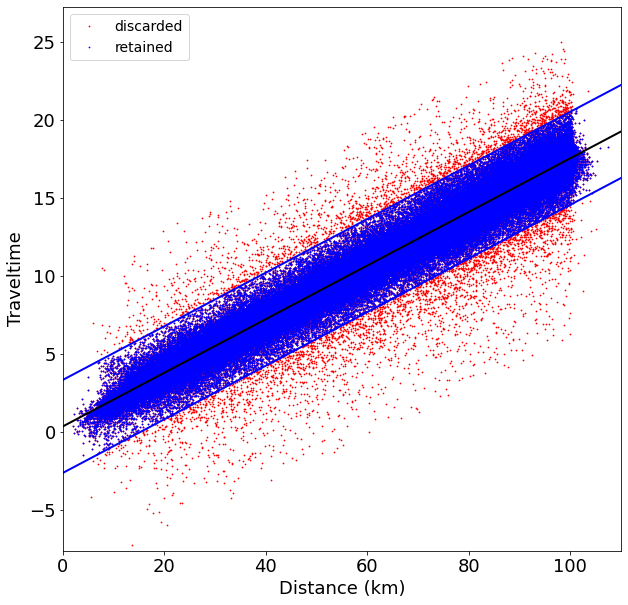

In [6]:
# 提取数据的 距离 与 走时
[dis_obs,time_obs] = ffd.data_dis_time(ev_limit_dis_phase,st_info_obs)
# 线性回归拟合
(slope,intercept,SEE) = ffd.linear_regression(dis_obs,time_obs)
up      =  3*SEE    # 上界
down    = -3*SEE    # 下界
print("The (slope,intercept,SEE) of original data is (%6.3f,%6.3f,%6.3f)"%(slope,intercept,SEE))

# 删除超过上下界的数据 （当 走时 > slope * 距离 + intercept + up 或者 走时 < slope * 距离 + intercept + down 时，认为是异常数据，剔除掉。）
dis_min = 0 
dis_max = 110
ev_remove_outlier_3SEE = ffd.fig_data_plot_remove_outliers(ev_limit_dis_phase,st_info_obs,slope,intercept,up,down,dis_min,dis_max, fname = "figs/step2_data_remove_outlier_3SEE.png")

# 评估删除数据之后的线性回归情况（可选）
(dis_obs,time_obs) = ffd.data_dis_time(ev_remove_outlier_3SEE,st_info_obs)
(slope_2,intercept_2,SEE_2) = ffd.linear_regression(dis_obs,time_obs)
print("The (slope,intercept,SEE) of filtered data is (%6.3f,%6.3f,%6.3f)"%(slope_2,intercept_2,SEE_2))

# 5. 数据输出

In [7]:
# 将数据输出到指定目录
import os

# 指定数据目录
out_path = "output_data"
os.makedirs(out_path,exist_ok=True)

# 储存为TomoATT格式数据文件
out_fname = "%s/step2_src_rec_remove_outlier.dat"%(out_path)
ffd.write_src_rec_file(out_fname,ev_remove_outlier_3SEE,st_info_obs)

src_rec.dat has been outputed: 64781 events, 93 stations, 262320 abs traveltime, 0 cs_dif traveltime, 0 cr_dif traveltime. 
earthquake and station region, lat:   -2.0 -    3.0, lon:   -1.3 -    1.3, dep:   -1.9 -   40.0
